A few notes on what each cell gives you:

Cell 3 — quick sanity check: how many records parsed, how many have violations, class balance
Cell 4 — the main view: every field side-by-side split by folder_label, so you can immediately spot where cat and non-cat videos differ in GPT's perception
Cell 5 — same information as a normalised heatmap, better for spotting proportional skew
Cell 6 — whether the model's overall_confidence actually correlates with visual_clarity (it should)
Cell 7 — a styled percentage table — useful to paste into a paper appendix

In [5]:
# Cell 1 — load
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

JSONL_PATH = "video_audio_human_validation/gpt_dataset_descriptions.jsonl"  # adjust if needed

records = []
with open(JSONL_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        flat = {
            "video_path": rec["video_path"],
            "folder_label": rec["folder_label"],
            "parse_ok": rec["parse_ok"],
            "has_violations": len(rec.get("consistency_violations", [])) > 0,
        }
        if rec["parse_ok"]:
            flat.update(rec["gpt_response"])
        records.append(flat)

df = pd.DataFrame(records)
print(f"{len(df)} records loaded — {df['parse_ok'].sum()} parsed ok, {(~df['parse_ok']).sum()} failed")
df.head()

4131 records loaded — 4131 parsed ok, 0 failed


,video_path,folder_label,parse_ok,has_violations,cat_present,num_cats,environment,scene_type,lighting,occlusion,visual_clarity,human_presence,other_animals_present,other_animals,cat_visual_type,overall_confidence
0,/Users/viktorzozula/Documents/Cats-in-Pain-Bac...,cat,True,False,yes,one,indoor,home,low_light,partial,slightly_blurry,no,no,[],tabby,high
1,/Users/viktorzozula/Documents/Cats-in-Pain-Bac...,cat,True,False,yes,one,outdoor,street,bright_daylight,none,slightly_blurry,no,no,[],domestic_longhair,high
2,/Users/viktorzozula/Documents/Cats-in-Pain-Bac...,cat,True,False,yes,one,outdoor,other,bright_daylight,partial,slightly_blurry,no,no,[],domestic_longhair,high
3,/Users/viktorzozula/Documents/Cats-in-Pain-Bac...,cat,True,False,yes,one,outdoor,other,bright_daylight,partial,slightly_blurry,no,no,[],domestic_longhair,high
4,/Users/viktorzozula/Documents/Cats-in-Pain-Bac...,cat,True,False,yes,one,outdoor,street,bright_daylight,partial,slightly_blurry,no,no,[],domestic_longhair,high


In [6]:
# Cell 2 — style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {"cat": "#3B6D11", "non-cat": "#993C1D"}
CAT_COLS = [
    "cat_present", "num_cats", "environment", "scene_type",
    "lighting", "occlusion", "visual_clarity", "human_presence",
    "other_animals_present", "cat_visual_type", "overall_confidence",
]

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_72018/3573483966.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parse_counts.index, y=parse_counts.values, ax=axes[0], palette=["#3B6D11", "#993C1D"])
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_72018/3573483966.py:6: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(x=parse_counts.index, y=parse_counts.values, ax=axes[0], palette=["#3B6D11", "#993C1D"])
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_72018/3573483966.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=viol_counts.index, y=viol_counts.values, ax=axes[1], palette=["#3B6D11"

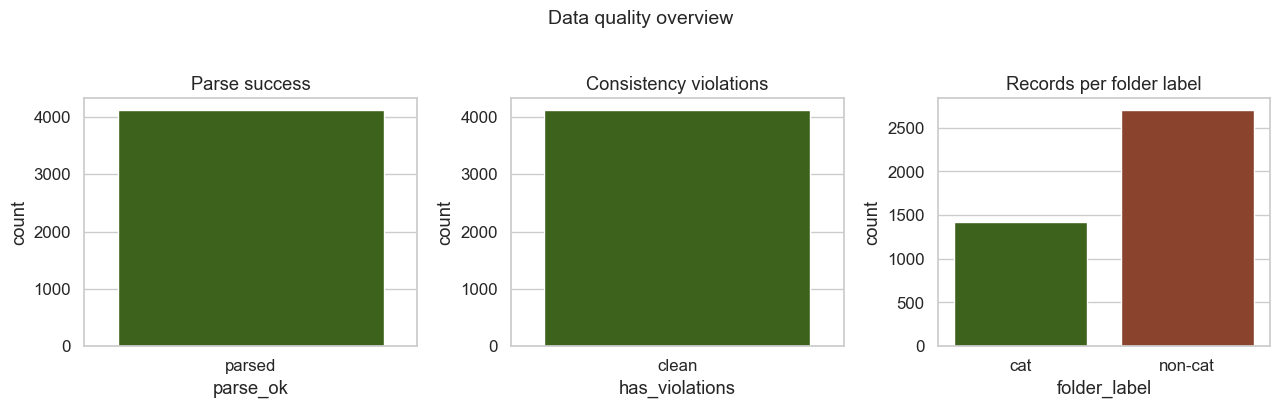

In [7]:
# Cell 3 — data quality overview
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# parse success
parse_counts = df["parse_ok"].value_counts().rename({True: "parsed", False: "failed"})
sns.barplot(x=parse_counts.index, y=parse_counts.values, ax=axes[0], palette=["#3B6D11", "#993C1D"])
axes[0].set_title("Parse success")
axes[0].set_ylabel("count")

# consistency violations
viol_counts = df["has_violations"].value_counts().rename({False: "clean", True: "violations"})
sns.barplot(x=viol_counts.index, y=viol_counts.values, ax=axes[1], palette=["#3B6D11", "#993C1D"])
axes[1].set_title("Consistency violations")
axes[1].set_ylabel("count")

# records per folder label
sns.countplot(data=df, x="folder_label", ax=axes[2], palette=PALETTE)
axes[2].set_title("Records per folder label")
axes[2].set_ylabel("count")

plt.suptitle("Data quality overview", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

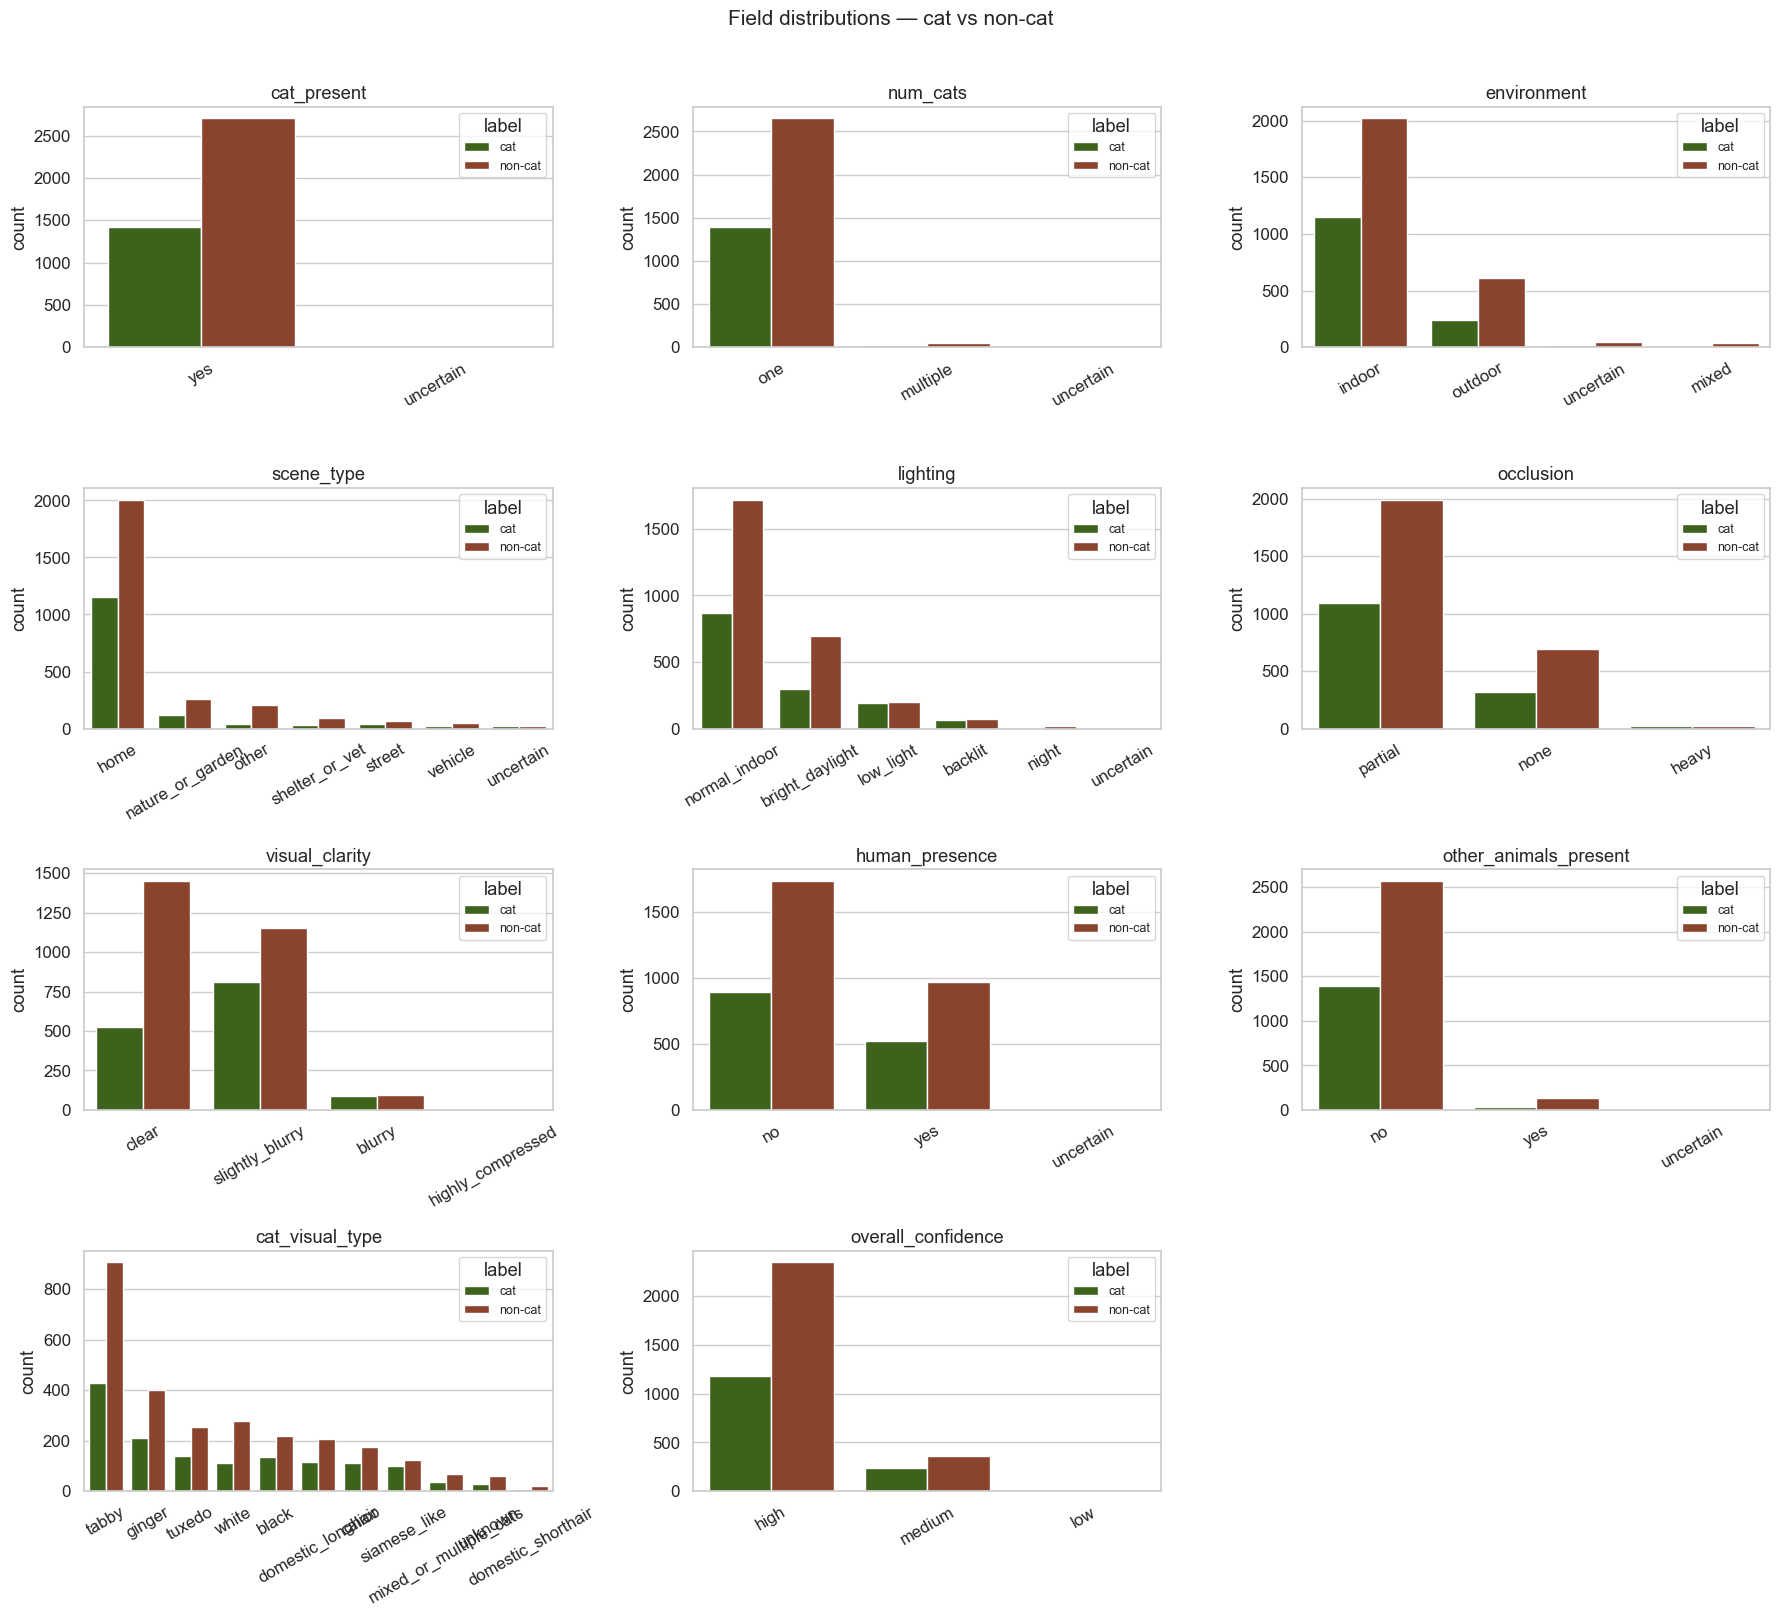

In [8]:
# Cell 4 — per-field distributions (cat vs non-cat)
df_ok = df[df["parse_ok"]].copy()

n_cols = 3
n_rows = -(-len(CAT_COLS) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    order = df_ok[col].value_counts().index.tolist()
    sns.countplot(
        data=df_ok, x=col, hue="folder_label",
        order=order, palette=PALETTE, ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="label", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Field distributions — cat vs non-cat", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

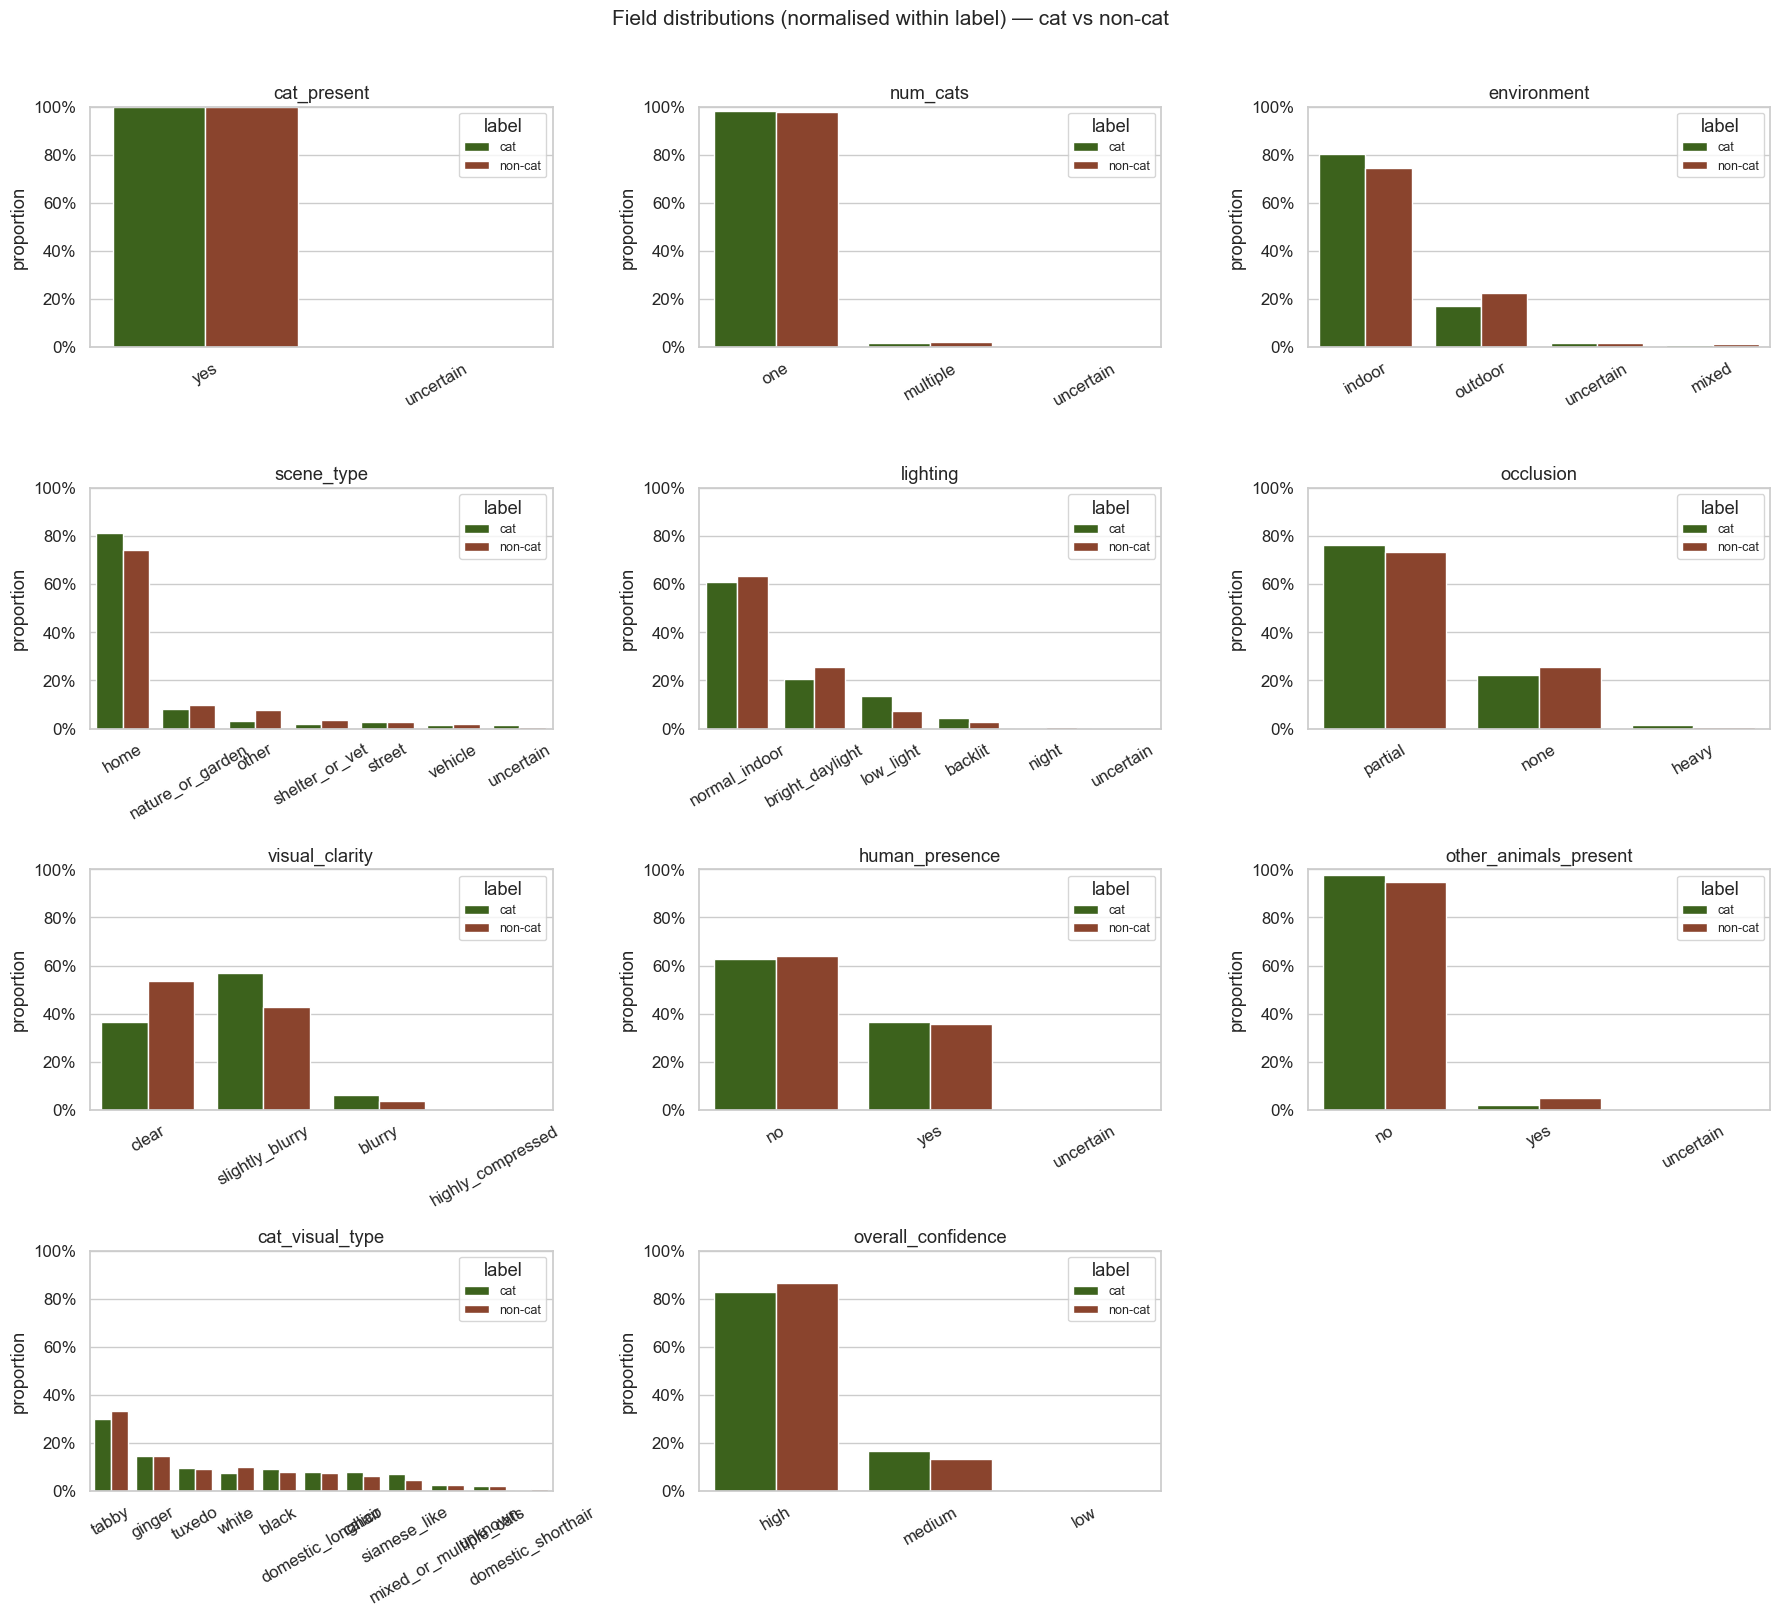

In [12]:
# Cell 4b — per-field distributions, normalised within each folder label
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    order = df_ok[col].value_counts().index.tolist()

    # compute proportion within each folder_label group
    norm = (
        df_ok.groupby(["folder_label", col])
        .size()
        .groupby(level=0)
        .transform(lambda x: x / x.sum())
        .reset_index(name="proportion")
    )

    sns.barplot(
        data=norm, x=col, y="proportion", hue="folder_label",
        order=order, palette=PALETTE, ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("proportion")
    axes[i].set_ylim(0, 1)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="label", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Field distributions (normalised within label) — cat vs non-cat", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

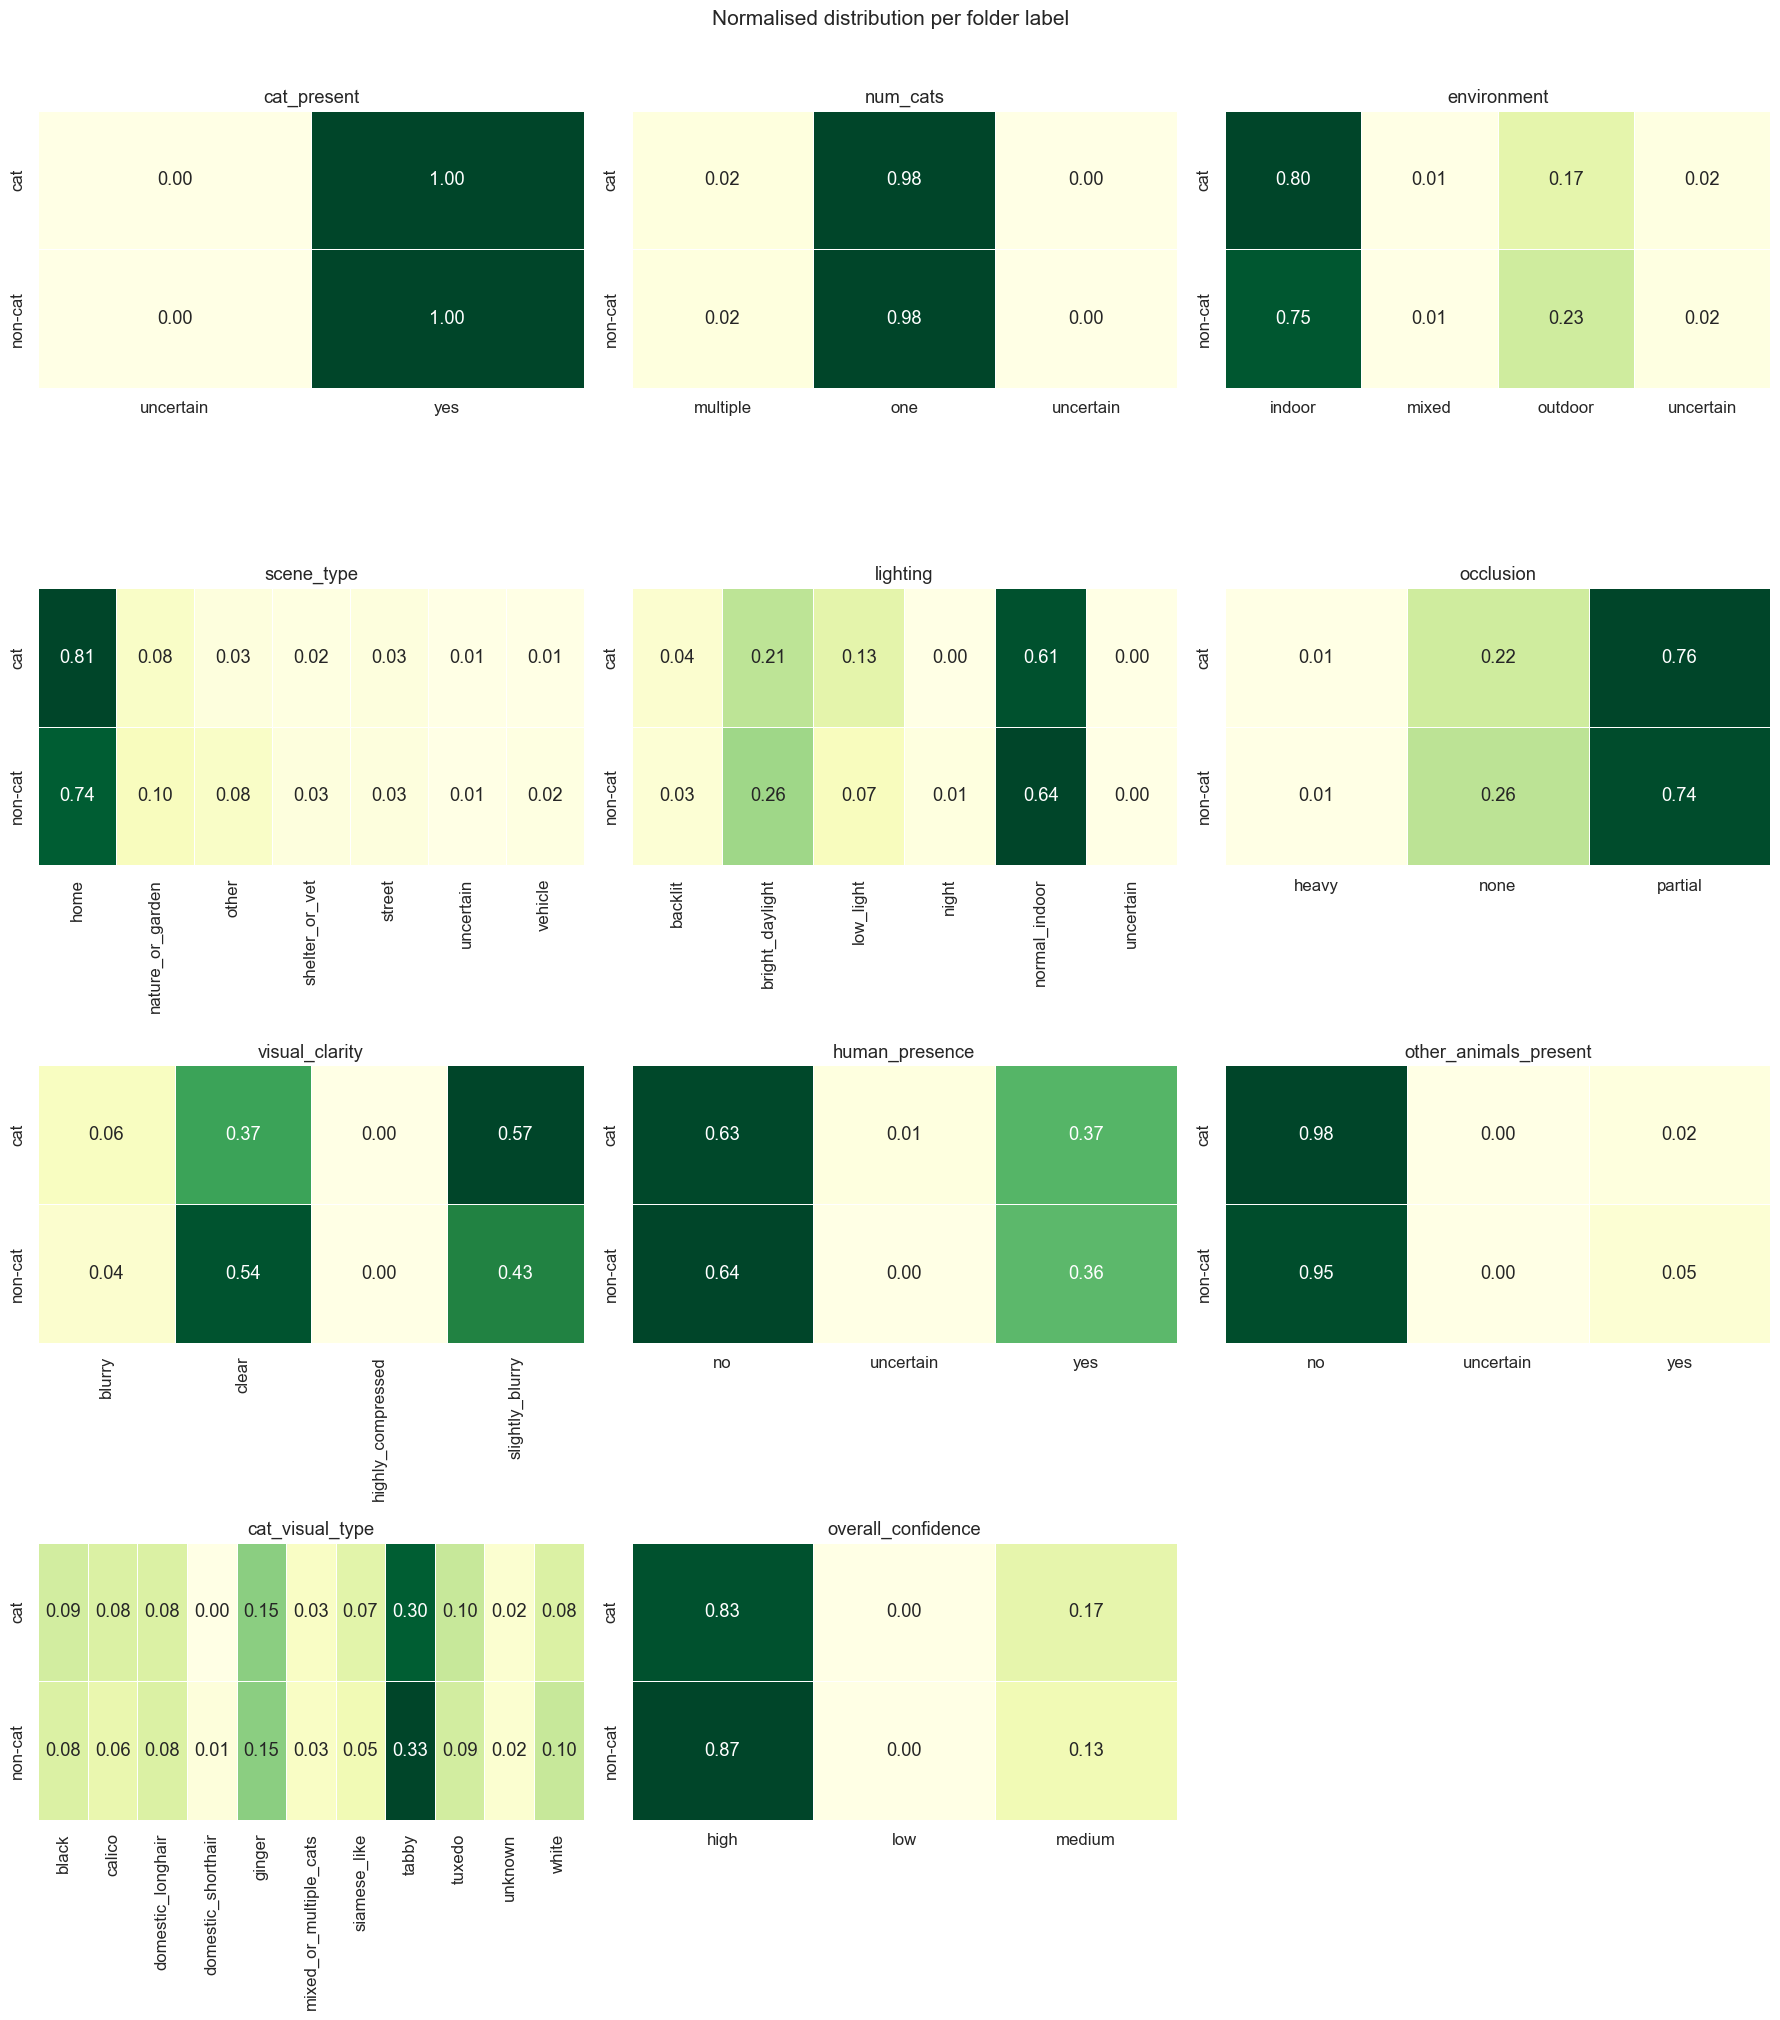

In [9]:
# Cell 5 — heatmap: folder label × each field (normalised)
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ct = pd.crosstab(df_ok["folder_label"], df_ok[col], normalize="index").round(2)
    sns.heatmap(
        ct, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.4, ax=axes[i], cbar=False
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Normalised distribution per folder label", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

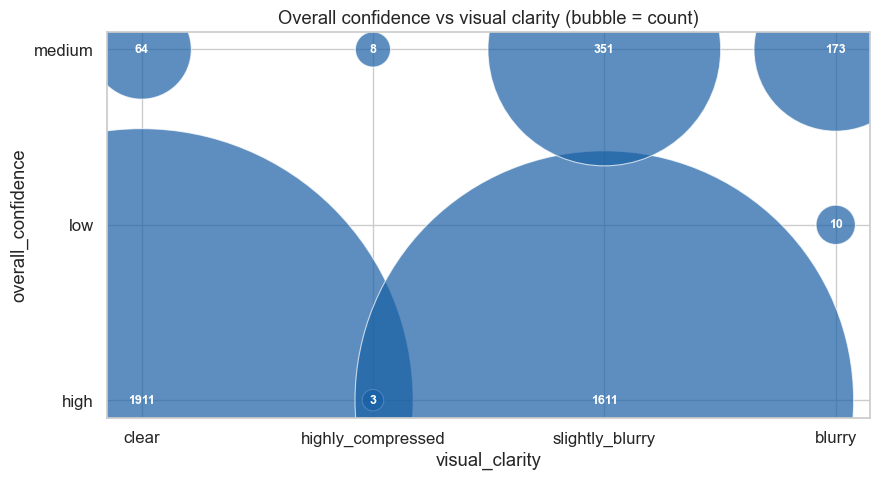

In [10]:
# Cell 6 — confidence × visual_clarity bubble chart
bubble = (
    df_ok.groupby(["overall_confidence", "visual_clarity"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    x=bubble["visual_clarity"],
    y=bubble["overall_confidence"],
    s=bubble["count"] * 80,
    alpha=0.7,
    color="#185FA5",
    edgecolors="white",
    linewidths=0.8,
)
for _, row in bubble.iterrows():
    ax.annotate(str(row["count"]), (row["visual_clarity"], row["overall_confidence"]),
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Overall confidence vs visual clarity (bubble = count)")
ax.set_xlabel("visual_clarity")
ax.set_ylabel("overall_confidence")
plt.tight_layout()
plt.show()

In [11]:
# Cell 7 — summary table
summary = pd.DataFrame({
    col: df_ok[col].value_counts(normalize=True).mul(100).round(1)
    for col in CAT_COLS
}).fillna(0).T

print("=== Value distribution (%) ===")
display(summary.style.background_gradient(cmap="YlGn", axis=1).format("{:.1f}"))

=== Value distribution (%) ===


,backlit,black,blurry,bright_daylight,calico,clear,domestic_longhair,domestic_shorthair,ginger,heavy,high,highly_compressed,home,indoor,low,low_light,medium,mixed,mixed_or_multiple_cats,multiple,nature_or_garden,night,no,none,normal_indoor,one,other,outdoor,partial,shelter_or_vet,siamese_like,slightly_blurry,street,tabby,tuxedo,uncertain,unknown,vehicle,white,yes
cat_present,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
num_cats,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.9,0.0,0.0,0.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
environment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.7,0.0,0.0,0.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.6,0.0,0.0,0.0,0.0
scene_type,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.2,0.0,0.0,0.0,0.0,0.0,6.1,0.0,0.0,2.9,0.0,0.0,2.7,0.0,0.0,0.9,0.0,1.6,0.0,0.0
lighting,3.3,0.0,0.0,23.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.5,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,62.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0
occlusion,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.5,0.0,0.0,0.0,0.0,74.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
visual_clarity,0.0,0.0,4.4,0.0,0.0,47.8,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
human_presence,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,36.1
other_animals_present,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,95.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,3.9
cat_visual_type,0.0,8.5,0.0,0.0,6.9,0.0,7.7,0.7,14.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.4,0.0,0.0,32.3,9.6,0.0,2.2,0.0,9.4,0.0
